In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
import platform
from matplotlib import rcParams

system = platform.system()

if system == "Windows":
    rcParams["font.family"] = "Meiryo"
elif system == "Darwin":  # macOS
    rcParams["font.family"] = "Hiragino Sans"
else:  # Linux
    rcParams["font.family"] = "IPAexGothic"

rcParams["font.size"] = 12

## Data Check

In [3]:
df_train = pd.read_csv("data/train.csv")

In [4]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
for col in ["Pclass", "Sex", "SibSp", "Parch", "Ticket", "Cabin", "Embarked"]:
    print(col, ":", df_train[col].unique())
    print('------------------------')

Pclass : [3 1 2]
------------------------
Sex : <StringArray>
['male', 'female']
Length: 2, dtype: str
------------------------
SibSp : [1 0 3 4 2 5 8]
------------------------
Parch : [0 1 2 5 3 4 6]
------------------------
Ticket : <StringArray>
[       'A/5 21171',         'PC 17599', 'STON/O2. 3101282',
           '113803',           '373450',           '330877',
            '17463',           '349909',           '347742',
           '237736',
 ...
           '349212',           '349217',           '349257',
             '7552', 'C.A./SOTON 34068',  'SOTON/OQ 392076',
           '211536',           '112053',           '111369',
           '370376']
Length: 681, dtype: str
------------------------
Cabin : <StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',    

In [7]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df_train[df_train["Age"].isna()].sample(5, random_state=42)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
82,83,1,3,"McDermott, Miss. Brigdet Delia",female,NaN,0,0,330932,7.7875,NaN,Q
235,236,0,3,"Harknett, Miss. Alice Phoebe",female,NaN,0,0,W./C. 6609,7.5500,NaN,S
667,668,0,3,"Rommetvedt, Mr. Knud Paust",male,NaN,0,0,312993,7.7750,NaN,S
158,159,0,3,"Smiljanic, Mr. Mile",male,NaN,0,0,315037,8.6625,NaN,S
347,348,1,3,"Davison, Mrs. Thomas Henry (Mary E Finck)",female,NaN,1,0,386525,16.1000,NaN,S


- Age, Cabin列に多くの欠損値があることが判明

## 探索的データ分析（EDA）

### カテゴリ特長量と生存率の関係

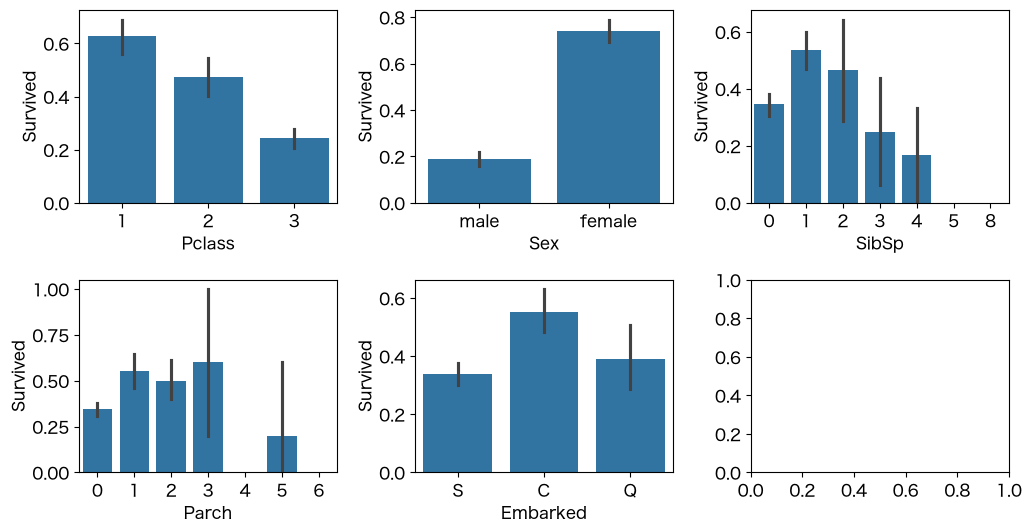

In [9]:
fig, axs = plt.subplots(2, 3, figsize=(12, 6))
axs = axs.ravel()
cols = ["Pclass", "Sex", "SibSp", "Parch", "Embarked"]

for i, ax in enumerate(axs):
    if i < len(cols):
        sns.barplot(df_train, x=cols[i], y="Survived", ax=ax)

plt.subplots_adjust(wspace=0.3, hspace=0.4)

plt.show()

- どの特徴量も生存率と関連がありそう
- 家族人数の多い乗客は協力して脱出でき生存率が高まった？
- クラスの高い人（≒ 裕福な人）は優先して脱出した？

### 連続数値型の特徴量と生存率の関係

In [10]:
df_train = pd.read_csv("data/train.csv")

In [11]:
df_train[["Age", "Fare"]].describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


In [12]:
df_train = df_train.copy()

In [13]:
df_train["Age_group"] = pd.cut(
    df_train["Age"], 
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80],
    labels=['9歳以下', '10代', '20代', '30代', '40代', '50代', '60代', '70代']
)
df_train[["Age", "Age_group"]].sample(5, random_state=42)

,Age,Age_group
709,NaN,NaN
439,31.0,30代
840,20.0,10代
720,6.0,9歳以下
39,14.0,10代


In [14]:
agg_df_age = df_train.groupby("Age_group")["Survived"].mean().reset_index()
agg_df_age['survived_ratio'] = agg_df_age['Survived'] * 100
agg_df_age['survived_ratio']

0    59.375000
1    38.260870
2    36.521739
3    44.516129
4    38.372093
5    40.476190
6    23.529412
7    20.000000
Name: survived_ratio, dtype: float64

In [15]:
df_train["Fare_group"] = pd.cut(
    df_train["Fare"], 
    bins=[0, 100, 200, 300, 400, 500, 600],
    labels=['100以下', '100~199', '200~299', '300~399', '400~499', '500~599']
)
df_train[["Fare", "Fare_group"]].sample(5, random_state=42)

,Fare,Fare_group
709,15.2458,100以下
439,10.5000,100以下
840,7.9250,100以下
720,33.0000,100以下
39,11.2417,100以下


In [16]:
agg_df_fare = df_train.groupby("Fare_group")["Survived"].mean().reset_index()
agg_df_fare['survived_ratio'] = agg_df_fare['Survived'] * 100
agg_df_fare['survived_ratio']

0     36.695018
1     75.757576
2     64.705882
3    100.000000
Name: survived_ratio, dtype: float64

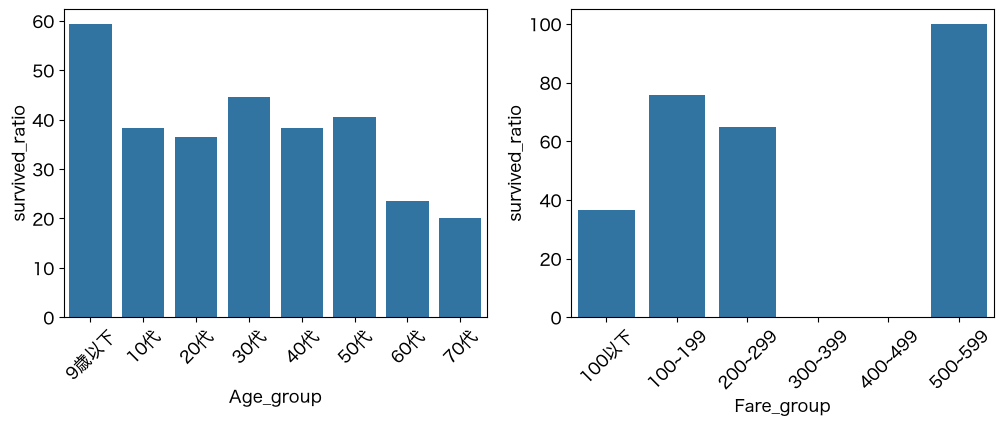

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(agg_df_age, x='Age_group', y='survived_ratio', ax=axs[0])
sns.barplot(agg_df_fare, x='Fare_group', y='survived_ratio', ax=axs[1])
axs[0].tick_params(axis='x', labelrotation=45)
axs[1].tick_params(axis='x', labelrotation=45)

plt.show()

- 子供は優先して脱出した？
- チケットが高い（≒ 裕福な人）は優先して脱出した？

### 外れ値の割合

In [18]:
df_train = pd.read_csv("data/train.csv")

In [19]:
missing_df_train = df_train.isnull().sum()
missing_df_train = missing_df_train[missing_df_train > 0].sort_values(ascending=False)
missing_percent = (missing_df_train / len(df_train)) * 100

missing_summary = pd.DataFrame({
    'null values': missing_df_train,
    'null ratio(%)': missing_percent
})
missing_summary

,null values,null ratio(%)
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


### 外れ値の可視化

In [20]:
df_train = pd.read_csv("data/train.csv")

In [21]:
df_train['Has_age'] = df_train['Age'].notnull()
df_train[df_train['Has_age'] == True].sample(5, random_state=42)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_age
149,150,0,2,"Byles, Rev. Thomas Roussel Davids",male,42.0,0,0,244310,13.00,NaN,S,True
407,408,1,2,"Richards, Master. William Rowe",male,3.0,1,1,29106,18.75,NaN,S,True
53,54,1,2,"Faunthorpe, Mrs. Lizzie (Elizabeth Anne Wilkin...",female,29.0,1,0,2926,26.00,NaN,S,True
369,370,1,1,"Aubart, Mme. Leontine Pauline",female,24.0,0,0,PC 17477,69.30,B35,C,True
818,819,0,3,"Holm, Mr. John Fredrik Alexander",male,43.0,0,0,C 7075,6.45,NaN,S,True


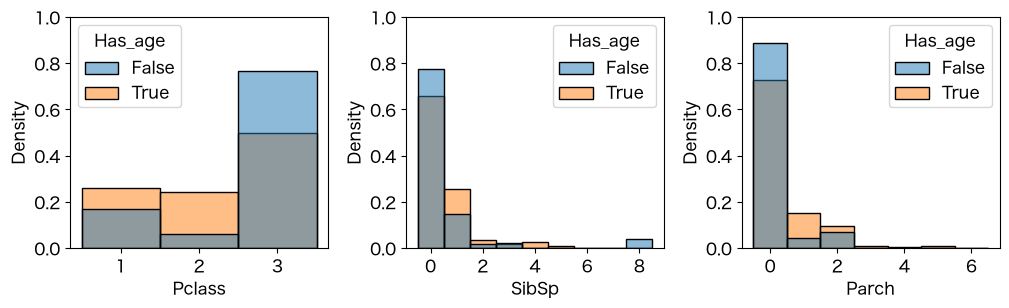

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
axs = axs.ravel()
cols = ["Pclass", "SibSp", "Parch"]

for i, ax in enumerate(axs):
    sns.histplot(
        df_train, 
        x=cols[i], 
        hue="Has_age", 
        binwidth=1,
        discrete=True,
        stat="density", 
        common_norm=False,
        ax=ax
    )
    ax.set_ylim(0, 1)

plt.subplots_adjust(wspace=0.3, hspace=0.4)

plt.show()

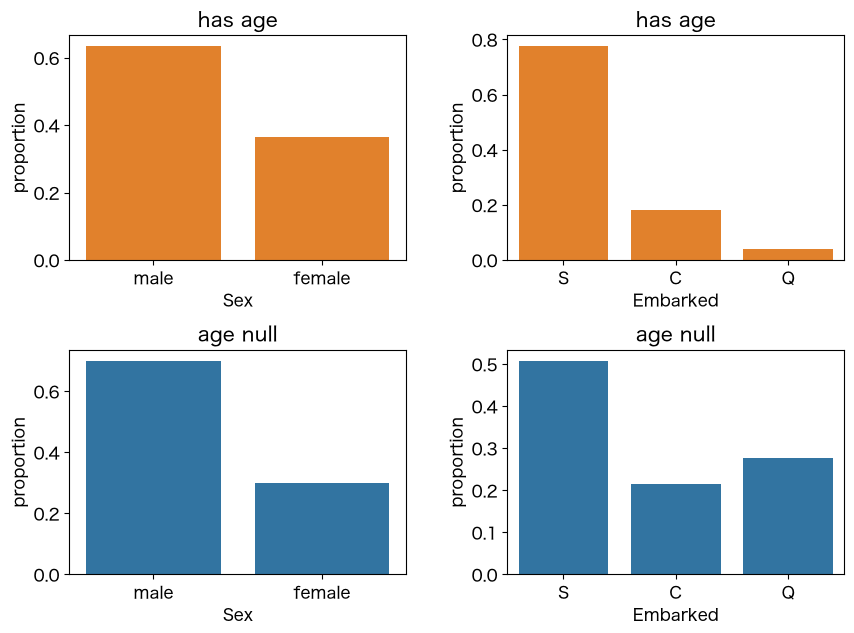

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(10, 7))
axs = axs.ravel()

conditions = [
    {
        "col": "Sex",
        "x_order": ["male", "female"],
        "has_age": True,
        "graph_title": "has age",
        "graph_color": "C1",
    },
    {
        "col": "Embarked",
        "x_order": ["S", "C", "Q"],
        "has_age": True,
        "graph_title": "has age",
        "graph_color": "C1",
    },
    {
        "col": "Sex",
        "x_order": ["male", "female"],
        "has_age": False,
        "graph_title": "age null",
        "graph_color": "C0",
    },
    {
        "col": "Embarked",
        "x_order": ["S", "C", "Q"],
        "has_age": False,
        "graph_title": "age null",
        "graph_color": "C0",
    },
]


for i, cond in enumerate(conditions):
    sns.countplot(
        df_train[df_train['Has_age'] == cond["has_age"]], 
        x=cond["col"],
        order=cond["x_order"],
        stat="proportion",
        color=cond["graph_color"],
        ax=axs[i],
    )
    axs[i].set_title(cond["graph_title"])

plt.subplots_adjust(wspace=0.3, hspace=0.4)

plt.show()

- Ageが存在するデータとnullのデータの間で他データの分布に目立って大きな差異はなさそうだが、チケットクラス（Pclass）が3rdの人と、乗船港（Embarked）がQ（Queenstown）の人は年齢データがない人が多い。

### missingnoを活用した欠損値分布の可視化

In [24]:
df_train = pd.read_csv("data/train.csv")

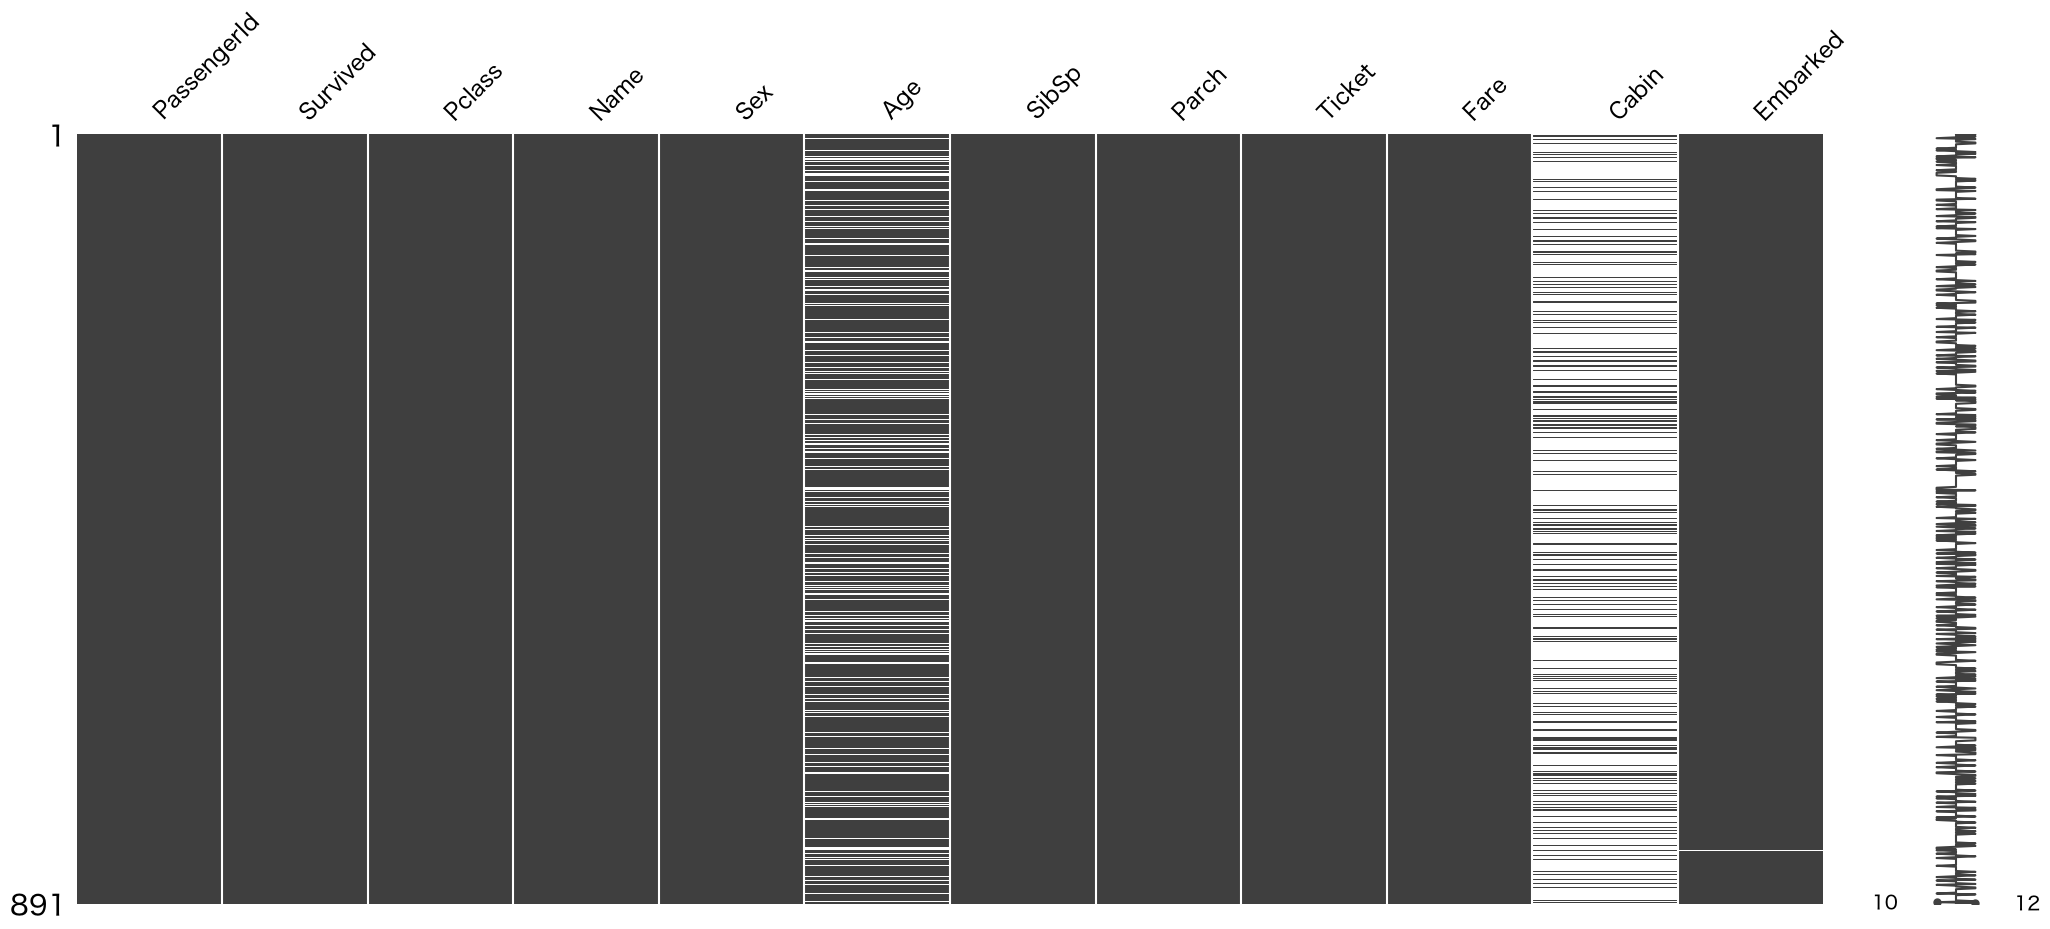

In [25]:
msno.matrix(df_train)
plt.show()

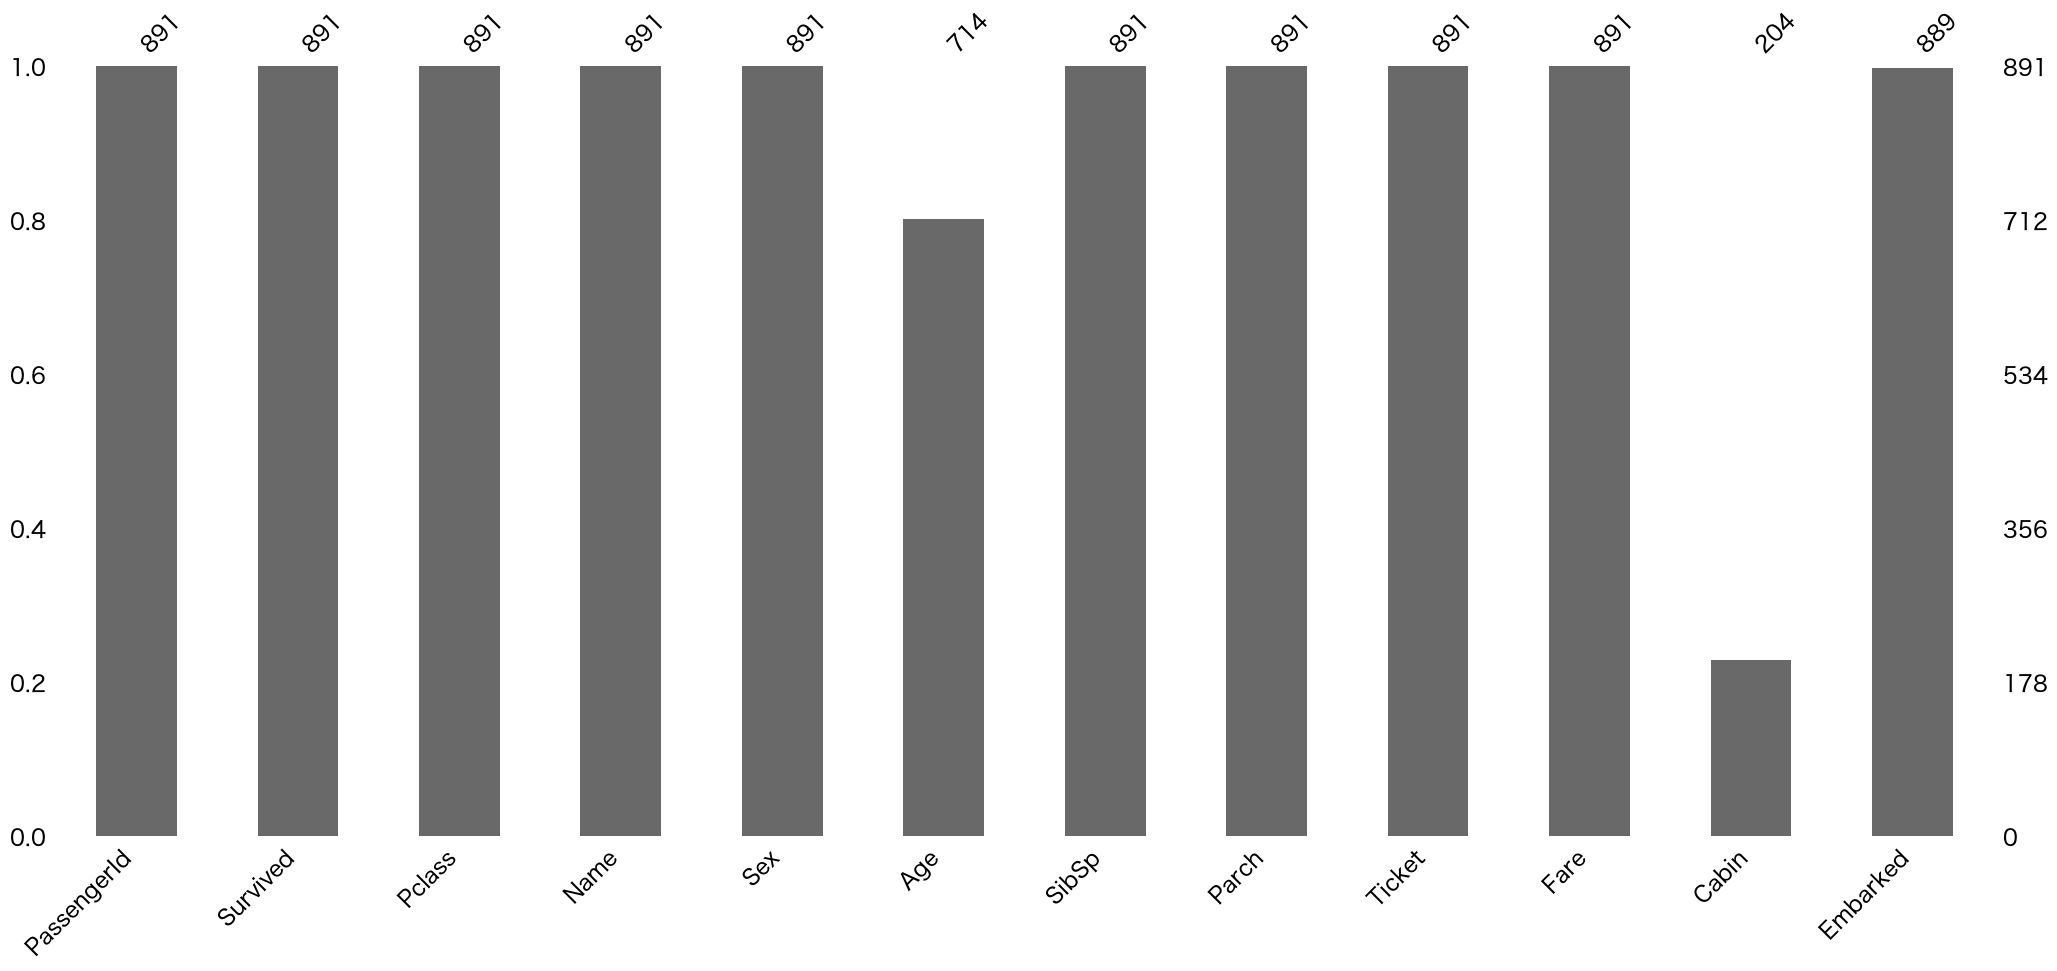

In [26]:
msno.bar(df_train)
plt.show()

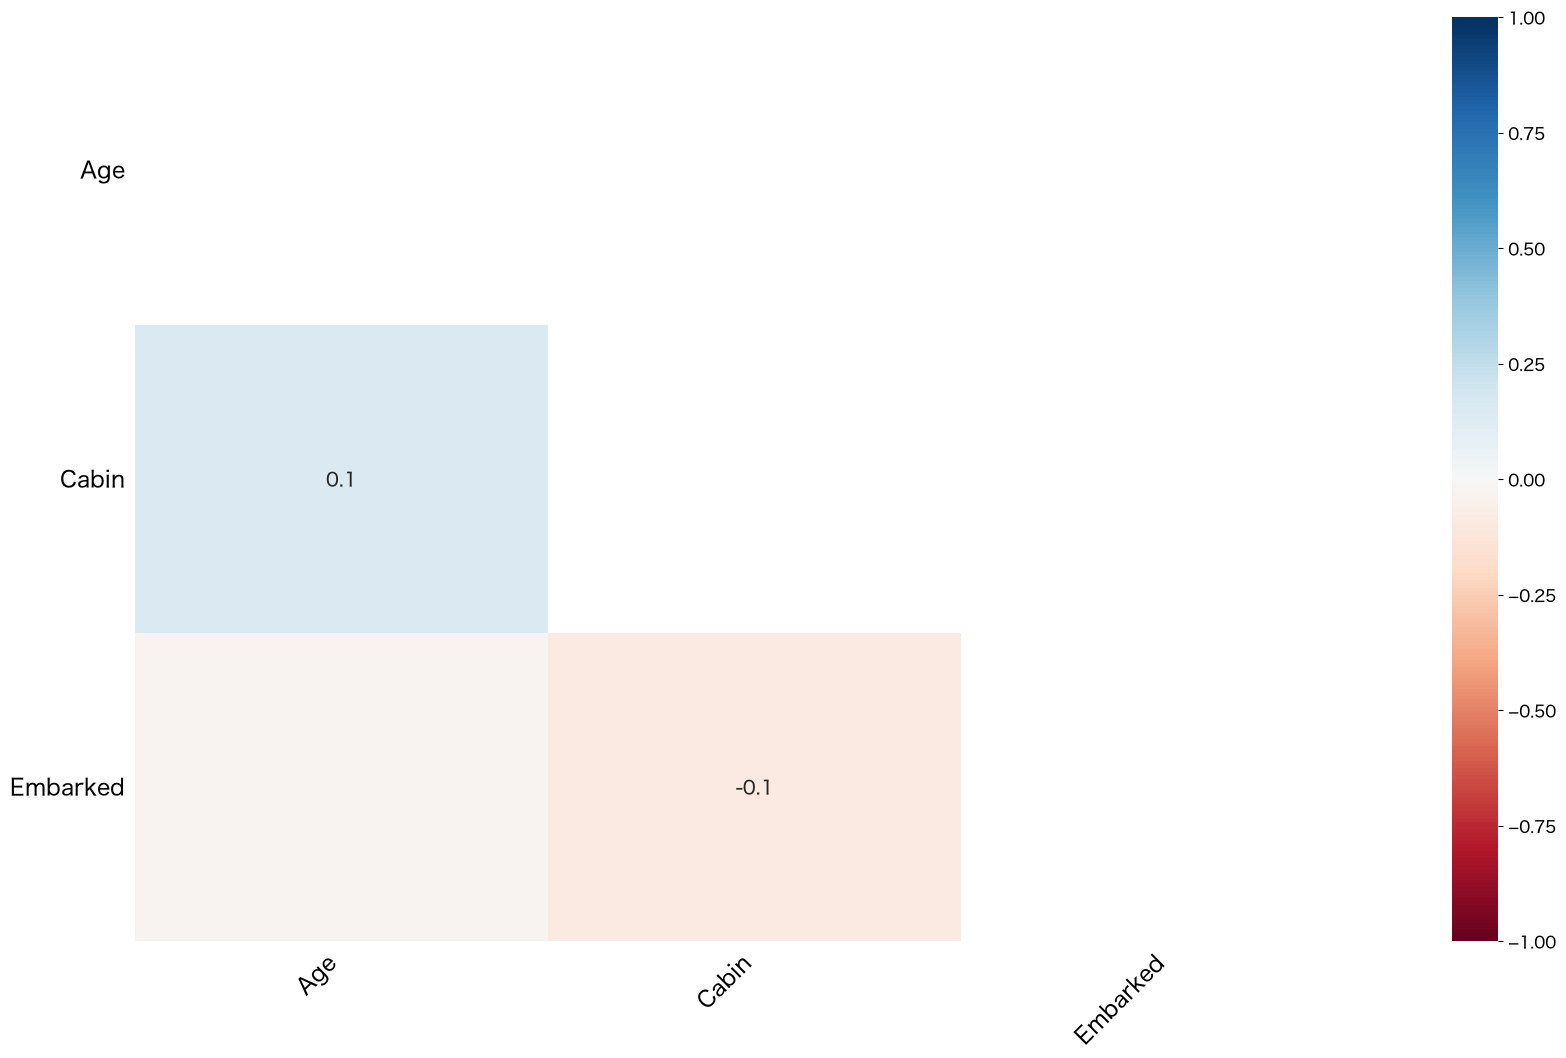

In [27]:
msno.heatmap(df_train)
plt.show()